# **Capstone Project: Providing data-driven suggestions for HR**

### Business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### The HR dataset

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

### Overview

The primary stakeholder for this initiative is the executive leadership team at Salifort Motors. The objective of this project is to develop a machine learning model capable of accurately predicting employee departure and to uncover the primary drivers contributing to turnover.

The analysis utilizes an HR dataset comprising 14,999 records and 10 workplace attributes. Exploratory Data Analysis (EDA) and predictive modeling will be executed in Python, leveraging libraries such as pandas for data manipulation, alongside ensemble methods including Random Forest and XGBoost.

From an ethical standpoint, this predictive model is strictly designed to serve as a decision-support tool rather than an automated decision-maker. It must not be utilized to penalize, discriminate against, or mistreat staff. Rather, algorithmic insights should trigger human interventions — such as internal feedback loops and collaborative discussions between management and employees — prior to any definitive HR actions.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [74]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier, plot_importance

### Initialize Dataset

In [75]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [76]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [77]:
# Check number of rows and columns
df0.shape

(14999, 10)

### Gather descriptive statistics about the data

In [78]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [79]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [80]:
# Reformat column names
df0.columns = df0.columns.str.lower()
df0 = df0.rename(columns={'average_montly_hours':'average_monthly_hours', 'time_spend_company':'tenure'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [81]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [82]:
# Check for duplicates
df0.duplicated().sum()

3008

In [83]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [84]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df0_subset = df0.drop_duplicates(ignore_index=True)

# Display first few rows of new dataframe as needed
df0_subset.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

Text(0.5, 0, 'Number of years')

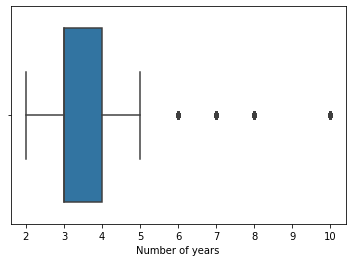

In [85]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
sns.boxplot(df0_subset['tenure']);
plt.xlabel('Number of years')

In [86]:
# Determine the number of rows containing outliers
Q1 = df0_subset['tenure'].quantile(0.25)
Q3 = df0_subset['tenure'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

lower_outliers = df0_subset[df0['tenure'] < lower].shape[0]
upper_outliers = df0_subset[df0['tenure'] > upper].shape[0]

print(lower_outliers + upper_outliers)

817


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [87]:
# Get numbers of people who left vs. stayed
print('Numbers of people who left vs. stayed')
print(df0_subset['left'].value_counts())
print('\n')

# Get percentages of people who left vs. stayed
print('Percentage of people who left vs. stayed')
print(df0_subset['left'].value_counts(normalize=True))

Numbers of people who left vs. stayed
0    10000
1     1991
Name: left, dtype: int64


Percentage of people who left vs. stayed
0    0.833959
1    0.166041
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

In [88]:
# Turn categorical variables into numerical
df0_dummies = pd.get_dummies(df0_subset, drop_first=True)

# Display first few rows of updated dataset
df0_dummies.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [89]:
# Create Pairwise Plot
# sns.pairplot(df0_dummies)

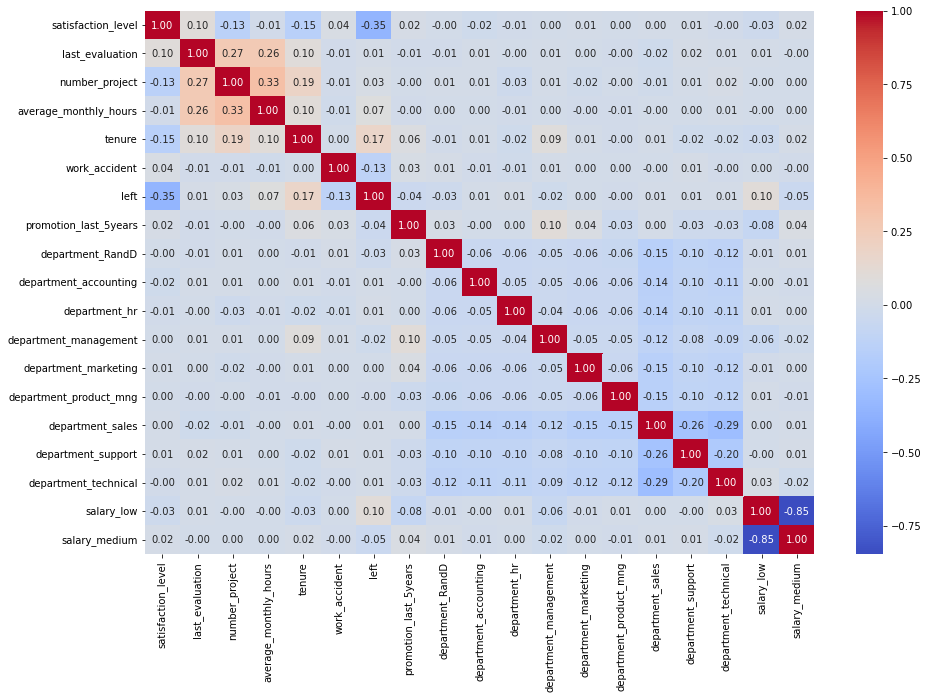

In [90]:
# Create heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df0_dummies.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

We are predicting the values for 'left', which would be a binary outcome.

### Identify the types of models most appropriate for this task.

We can use a decision or random tree model due to their robustness against outliers that are present in the dataset and the complexity of the model since we will be using all the attributes as our independent variables. 

### Modeling

Add as many cells as you need to conduct the modeling process.

In [91]:
# Set predictor and outcome variables
X = df0_dummies.drop(columns=['left'])
y = df0_dummies['left']

# Split dataset into training, testing, and validation data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

In [92]:
# Label training and validation data
split_index = [0 if x in X_val.index else -1 for x in X_train.index]
custom_split = PredefinedSplit(split_index)

In [93]:
%%time

# Create random forest model and cross-validate
rf = RandomForestClassifier(random_state=42)

cv_params = {'n_estimators':[75, 100],
             'max_depth':[8,9,10],
             'min_samples_leaf':[2, 3],
             'min_samples_split':[2, 3],
             'max_features':[5,6,7]
            }

scoring = {'accuracy', 'precision', 'recall', 'f1'}

# rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=custom_split, refit='f1')
# rf_cv.fit(X_train, y_train)

CPU times: user 33 µs, sys: 6 µs, total: 39 µs
Wall time: 47.7 µs


In [94]:
# Pickle Model
import pickle

# with open('rf_cv_model.pickle', 'wb') as to_write:
#     pickle.dump(rf_cv, to_write)

with open('rf_cv_model.pickle', 'rb') as to_read:
    rf_cv = pickle.load(to_read)

## Evaluation metrics

- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




In [95]:
# Show hyperparameters of best performing random forest model
rf_cv.best_params_

{'max_depth': 8,
 'max_features': 6,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 75}

In [96]:
# Fit the optimal model
rf_opt = RandomForestClassifier(n_estimators=75, max_depth=8, max_features=6, min_samples_leaf=2, min_samples_split=2, random_state=0)
rf_opt.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=8, max_features=6,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=2, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=75,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

In [97]:
# Predict using validation data
y_pred = rf_opt.predict(X_val)

In [98]:
# Calculate precision score
pc_test = precision_score(y_val, y_pred)
print(f'Precision Score: {pc_test}')

# Calculate recall score
rc_test = recall_score(y_val, y_pred)
print(f'Recall Score: {rc_test}')

# Calculate accuracy score
ac_test = accuracy_score(y_val, y_pred)
print(f'Accuracy Score: {ac_test}')

# Calculate F1 score
f1_test = f1_score(y_val, y_pred)
print(f'F1 Score: {f1_test}')

Precision Score: 0.9814814814814815
Recall Score: 0.9321608040201005
Accuracy Score: 0.9858215179316097
F1 Score: 0.9561855670103092


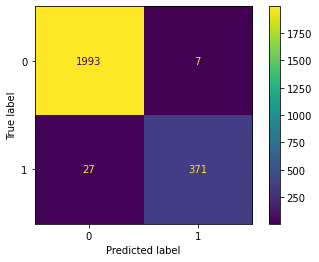

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix for y_val vs. y_pred

cm = confusion_matrix(y_val, y_pred, labels=rf_opt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_opt.classes_)
disp.plot(values_format='')

In [100]:
# Generate classification report of the optimal random forest model
target_labels = ['employed', 'left']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    employed       0.99      1.00      0.99      2000
        left       0.98      0.93      0.96       398

    accuracy                           0.99      2398
   macro avg       0.98      0.96      0.97      2398
weighted avg       0.99      0.99      0.99      2398



## XGBoost Model

In [101]:
%%time

# Create XGBoost model and cross-validate

xgb = XGBClassifier(objective='binary:logistic', random_state=42)

cv_params_xgb = {'max_depth': [4, 6],
                 'learning_rate': [0.01, 0.1],
                 'n_estimators': [100, 200]
                }

scoring = ['accuracy', 'precision', 'recall', 'f1']

# xgb_cv = GridSearchCV(xgb, cv_params_xgb, scoring=scoring, cv=custom_split, refit='f1', verbose=2)
# xgb_cv.fit(X_train, y_train)

CPU times: user 35 µs, sys: 6 µs, total: 41 µs
Wall time: 49.1 µs


In [102]:
# with open('xgb_cv_model.pickle', 'wb') as to_write:
#     pickle.dump(xgb_cv, to_write)

with open('xgb_cv_model.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [103]:
# Show hyperparameters of the optimal XGBoost model
xgb_cv.best_params_

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}

In [104]:
# Predict using optimal XGBoost model
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val)

In [105]:
# Calculate precision score
pc_xgb = precision_score(y_val, y_pred_xgb)
print(f'Precision Score: {pc_xgb}')

# Calculate recall score
rc_xgb = recall_score(y_val, y_pred_xgb)
print(f'Recall Score: {rc_xgb}')

# Calculate accuracy score
ac_xgb = accuracy_score(y_val, y_pred_xgb)
print(f'Accuracy Score: {ac_xgb}')

# Calculate F1 score
f1_xgb = f1_score(y_val, y_pred_xgb)
print(f'F1 Score: {f1_xgb}')

Precision Score: 0.9894736842105263
Recall Score: 0.9447236180904522
Accuracy Score: 0.9891576313594662
F1 Score: 0.9665809768637531


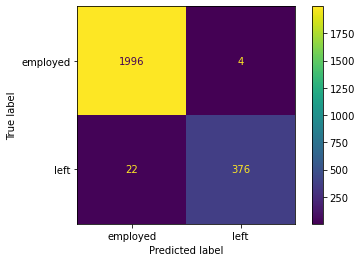

In [106]:
# Create confusion matrix for y_val vs. y_pred_xgb
cm_2 = confusion_matrix(y_val, y_pred_xgb)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=['employed', 'left'])
disp_2.plot(values_format='')

In [107]:
# Create classification report for the optimal XGBoost model
target_labels = ['employed', 'left']
print(classification_report(y_val, y_pred_xgb, target_names=target_labels))

              precision    recall  f1-score   support

    employed       0.99      1.00      0.99      2000
        left       0.99      0.94      0.97       398

    accuracy                           0.99      2398
   macro avg       0.99      0.97      0.98      2398
weighted avg       0.99      0.99      0.99      2398



## Champion Model Prediction (RF)

In [108]:
# Predict using test data and optimal XGBoost / champion model 
y_pred_champ = xgb_cv.best_estimator_.predict(X_test)

# Calculate precision score
pc_champ = precision_score(y_test, y_pred_champ)
print(f'Precision Score: {pc_champ}')

# Calculate recall score
rc_champ = recall_score(y_test, y_pred_champ)
print(f'Recall Score: {rc_champ}')

# Calculate accuracy score
ac_champ = accuracy_score(y_test, y_pred_champ)
print(f'Accuracy Score: {ac_champ}')

# Calculate F1 score
f1_champ = f1_score(y_test, y_pred_champ)
print(f'F1 Score: {f1_champ}')

Precision Score: 0.9710526315789474
Recall Score: 0.9271356783919598
Accuracy Score: 0.9833263859941642
F1 Score: 0.9485861182519281


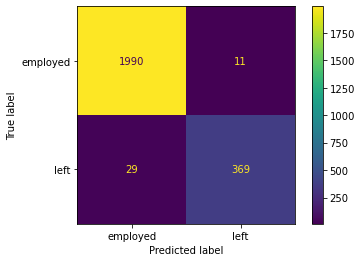

In [109]:
# Create confusion matrix for y_val vs. y_pred_champ
cm_champ = confusion_matrix(y_test, y_pred_champ)
disp_champ = ConfusionMatrixDisplay(confusion_matrix=cm_champ, display_labels=['employed', 'left'])
disp_champ.plot(values_format='')

In [110]:
# Create classification report for champion model
target_labels = ['employed', 'left']
print(classification_report(y_test, y_pred_champ, target_names=target_labels))

              precision    recall  f1-score   support

    employed       0.99      0.99      0.99      2001
        left       0.97      0.93      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



### Feature Importances

In [111]:
# Show features sorted by importance
importances = xgb_cv.best_estimator_.feature_importances_
xgb_importances = pd.Series(importances, index=X_test.columns)

xgb_importances.sort_values(ascending=False)

satisfaction_level        0.298497
tenure                    0.194024
number_project            0.179860
last_evaluation           0.122232
average_monthly_hours     0.061481
work_accident             0.028705
salary_medium             0.018882
salary_low                0.018444
department_sales          0.014741
department_hr             0.014126
department_management     0.010550
department_support        0.009827
department_RandD          0.009315
department_technical      0.008592
department_product_mng    0.005483
department_accounting     0.004994
department_marketing      0.000248
promotion_last_5years     0.000000
dtype: float32

In [112]:
# Calculate mean for each attribute grouped by 'left' status
df0_subset.groupby('left').mean()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years
left,,,,,,,
0,0.667365,0.715667,3.786800,198.94270,3.262000,0.174500,0.019500
1,0.440271,0.721783,3.883476,208.16223,3.881467,0.052737,0.004018


### Additional Visualizations

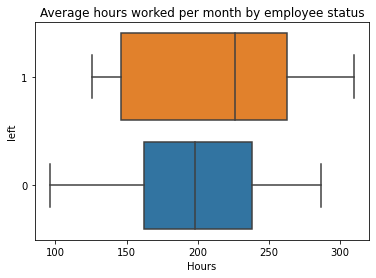

In [145]:
ax = sns.boxplot(data=df0_subset, x='average_monthly_hours', y='left', orient='h')
ax.invert_yaxis()
ax.set_xlabel('Hours')
ax.set_title('Average hours worked per month by employee status')
plt.show()

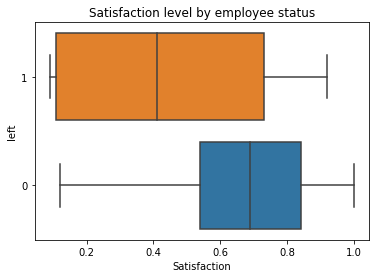

In [144]:
ax2 = sns.boxplot(data=df0_subset, x='satisfaction_level', y='left', orient='h')
ax2.invert_yaxis()
ax2.set_xlabel('Satisfaction')
ax2.set_title('Satisfaction level by employee status')
plt.show()

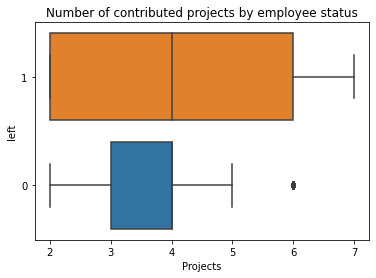

In [149]:
ax3 = sns.boxplot(data=df0_subset, x='number_project', y='left', orient='h')
ax3.invert_yaxis()
ax3.set_xlabel('Projects')
ax3.set_title('Number of contributed projects by employee status')
plt.show()

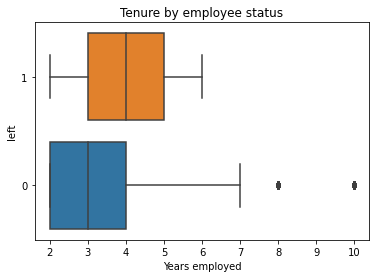

In [147]:
ax4 = sns.boxplot(data=df0_subset, x='tenure', y='left', orient='h')
ax4.invert_yaxis()
ax4.set_xlabel('Years employed')
ax4.set_title('Tenure by employee status')
plt.show()

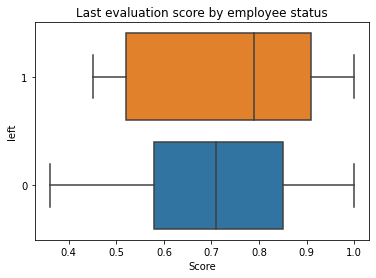

In [148]:
ax5 = sns.boxplot(data=df0_subset, x='last_evaluation', y='left', orient='h')
ax5.invert_yaxis()
ax5.set_xlabel('Score')
ax5.set_title('Last evaluation score by employee status')
plt.show()

### Conclusion, Recommendations, Next Steps

**Key Findings**

We have successfully developed a highly accurate predictive model to identify employees at risk of leaving Salifort Motors. Validated against real test data, the model delivers 98.3% overall accuracy, 97.1% precision, and 92.7% recall. This means when the model flags an employee as a flight risk, it is almost always correct, allowing proactive intervention and minimizing the high costs associated with offboarding and replacing talent.

Out of 2,399 tested employee profiles, the model correctly predicted 2,359 outcomes. It missed 29 employees who ultimately left (false negatives) and flagged only 11 who chose to stay (false positives), proving to be an exceptionally reliable tool for predicting whether or not an employee will leave.

Our analysis isolated the workplace factors that contributed most to employee departures. Ranked by statistical importance, the primary factors are:

- Employee's self-reported satisfaction level — employees that left had lower satisfaction levels on average.

- Tenure (Time spent at the company) — employees that left had longer average tenure compared to those who stayed.

- Number of projects employee contributes to — employees that left were more likely to contribute to less or more projects compared to those who stayed.

- Score of employee's last performance review — employees that left had better performance scores on average (possibly due to working more hours).

- Average number of hours employee worked per month — employees that left worked more hours per month on average.

**Strategic Recommendations**

To maximize employee retention and maintain morale, we recommend the HR department implement the following data-driven initiatives based on our findings:

- Establish thresholds for monthly working hours to prevent burnout before employees hit critical retention risk levels. 

- Re-assess performance evaluation rubric to prevent the rewarding of overwork; emphasize output quality and objective achievements rather than excessive working hours.

- Utilize surveys or check-ins and take in feedback from employees showing lower satisfaction scores.

- Introduce loyalty incentives, clear career progression pathways, or adjusted compensation structures tailored to employees entering their highest-risk tenure years.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.